In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
from matplotlib import pyplot as plt  

In [3]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [4]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(42000, 785)

In [6]:
df['label']

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [7]:
df.isnull().sum().sum() # checking if any null values

np.int64(0)

In [8]:
df.duplicated().sum() # checking if there any duplicates 

np.int64(0)

In [9]:
labels = df["label"].values
pixels = df.drop(columns="label").values
print("pixel min/max:", pixels.min(), pixels.max())
print("share of pixels equal to 0: {:.1%}".format((pixels == 0).mean()))

pixel min/max: 0 255
share of pixels equal to 0: 80.8%


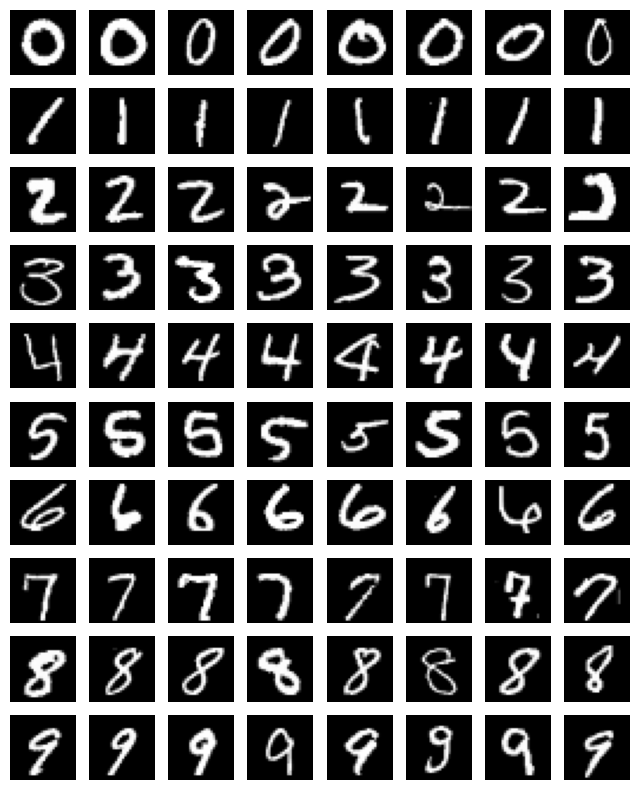

In [10]:
fig, axes = plt.subplots(10, 8, figsize=(8, 10))
for d in range(10):
    idxs = np.where(labels == d)[0][:8]
    for j, idx in enumerate(idxs):
        axes[d, j].imshow(pixels[idx].reshape(28, 28), cmap="gray")
        axes[d, j].axis("off")
plt.show()

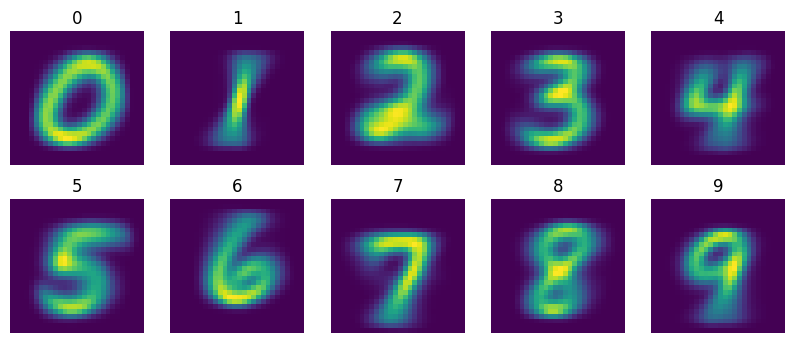

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for d, ax in enumerate(axes.ravel()):
    ax.imshow(pixels[labels == d].mean(axis=0).reshape(28, 28))
    ax.set_title(d); ax.axis("off")
plt.show()

In [12]:
counts = df["label"].value_counts().sort_index()
print(counts)

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


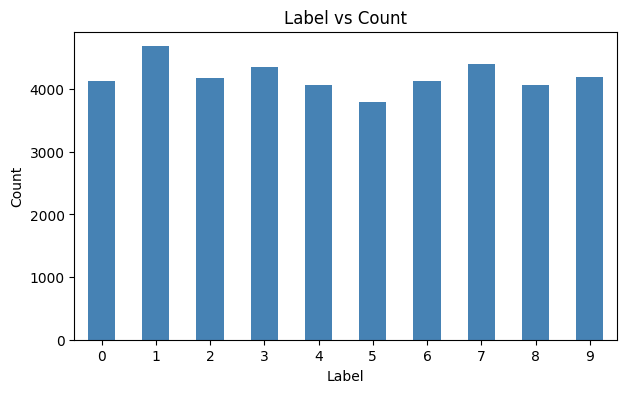

In [13]:
counts.plot(kind="bar", color="steelblue", figsize=(7, 4))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label vs Count")
plt.xticks(rotation=0)
plt.show()

In [14]:
df =np.array(df)
m,n = df.shape

np.random.shuffle(df)

df_dev =df[0:1000].T
Y_dev =df_dev[0]
X_dev = df_dev[1:n]/255

df_train = df[1000:m].T
Y_train =df_train[0]
X_train = df_train[1:n]/255

In [15]:
def init_params(hidden=128):
    W1 = np.random.randn(hidden, 784) * np.sqrt(2 / 784)
    b1 = np.zeros((hidden, 1))
    W2 = np.random.randn(10, hidden) * np.sqrt(2 / hidden)
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

def cross_entropy(A2, Y):
    return -np.mean(np.sum(one_hot(Y) * np.log(A2 + 1e-12), axis=0))

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    e = np.exp(Z - np.max(Z, axis=0))
    return e / np.sum(e, axis=0)
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def deriv_ReLU(Z):
    return Z > 0

def one_hot(Y):
    Y = Y.astype(int)
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)   
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)   
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2


In [38]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X )
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 50 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions ,Y))
    return W1, b1, W2, b2

In [31]:
W1 , b1 , W2 , b2 = gradient_descent(X_train , Y_train , 0.1 ,500)

Iteration:  0
[2 2 6 ... 6 6 2] [1 9 3 ... 3 3 6]
0.10417073170731707
Iteration:  50
[1 9 3 ... 3 3 6] [1 9 3 ... 3 3 6]
0.856
Iteration:  100
[1 9 3 ... 3 3 6] [1 9 3 ... 3 3 6]
0.8845365853658537
Iteration:  150
[1 9 3 ... 3 3 6] [1 9 3 ... 3 3 6]
0.8964878048780488
Iteration:  200
[1 9 3 ... 3 3 6] [1 9 3 ... 3 3 6]
0.9037317073170732
Iteration:  250
[1 9 3 ... 3 3 6] [1 9 3 ... 3 3 6]
0.9094634146341464
Iteration:  300
[1 9 3 ... 3 3 6] [1 9 3 ... 3 3 6]
0.9137560975609756
Iteration:  350
[1 9 3 ... 3 3 6] [1 9 3 ... 3 3 6]
0.9179268292682927
Iteration:  400
[1 9 3 ... 3 3 6] [1 9 3 ... 3 3 6]
0.9209024390243903
Iteration:  450
[1 9 3 ... 3 3 6] [1 9 3 ... 3 3 6]
0.923829268292683


In [32]:
X_test, Y_test = X_train[:, :2000], Y_train[:2000]
X_train, Y_train = X_train[:, 2000:], Y_train[2000:]

In [33]:
def train(lr=0.1, bs=128, epochs=15, hidden=128):
    W1,b1,W2,b2 = init_params(hidden); m = X_train.shape[1]
    h = {'tl':[], 'vl':[], 'ta':[], 'va':[]}
    for e in range(epochs):
        p = np.random.permutation(m)
        for i in range(0, m, bs):
            idx = p[i:i+bs]; Xb, Yb = X_train[:, idx], Y_train[idx]
            Z1,A1,Z2,A2 = forward_prop(W1,b1,W2,b2,Xb)
            g = back_prop(Z1,A1,Z2,A2,W2,Xb,Yb)
            W1,b1,W2,b2 = update_params(W1,b1,W2,b2,*g,lr)
        for X,Y,k in ((X_train,Y_train,'t'), (X_dev,Y_dev,'v')):
            A2 = forward_prop(W1,b1,W2,b2,X)[3]
            h[k+'l'].append(cross_entropy(A2,Y)); h[k+'a'].append((A2.argmax(0)==Y).mean())
    return (W1,b1,W2,b2), h

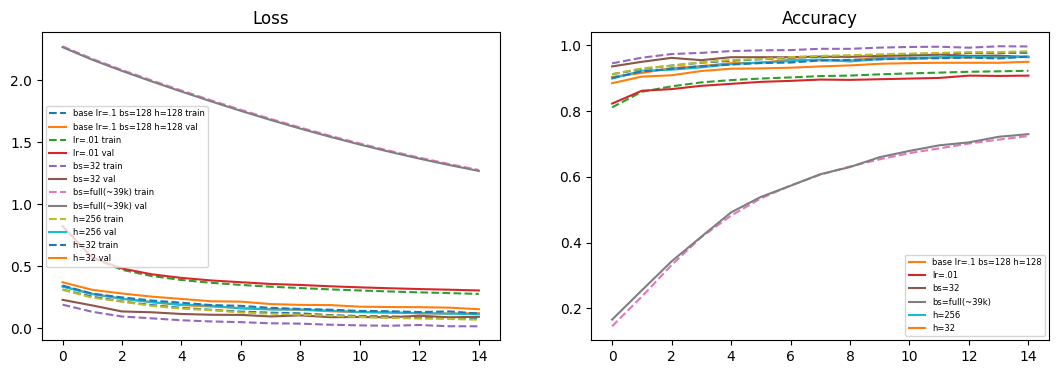

base lr=.1 bs=128 h=128      val_acc=0.9660
lr=.01                       val_acc=0.9080
bs=32                        val_acc=0.9640
bs=full(~39k)                val_acc=0.7300
h=256                        val_acc=0.9650
h=32                         val_acc=0.9500


In [34]:
cfgs = {'base lr=.1 bs=128 h=128': dict(),
        'lr=.01':                  dict(lr=0.01),
        'bs=32':                   dict(bs=32),
        'bs=full(~39k)':           dict(bs=X_train.shape[1]),
        'h=256':                   dict(hidden=256),
        'h=32':                    dict(hidden=32)}
res = {k: train(**v) for k, v in cfgs.items()}

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, (_, h) in res.items():
    ax[0].plot(h['tl'], '--', label=k+' train'); ax[0].plot(h['vl'], label=k+' val')
    ax[1].plot(h['ta'], '--'); ax[1].plot(h['va'], label=k)
ax[0].set_title('Loss'); ax[1].set_title('Accuracy'); ax[0].legend(fontsize=6); ax[1].legend(fontsize=6)
plt.show()
for k, (_, h) in res.items(): print(f"{k:28s} val_acc={h['va'][-1]:.4f}")

In [35]:
best = max(res, key=lambda k: res[k][1]['va'][-1]); W1,b1,W2,b2 = res[best][0]; print(best)

base lr=.1 bs=128 h=128


Accuracy: 0.9625
   precision  recall     f1
0      0.973   0.967  0.970
1      0.991   0.987  0.989
2      0.957   0.973  0.965
3      0.974   0.931  0.952
4      0.968   0.943  0.955
5      0.957   0.937  0.947
6      0.967   0.978  0.973
7      0.968   0.973  0.970
8      0.919   0.970  0.944
9      0.950   0.963  0.956
Macro P/R/F1: 0.9625 0.9621 0.9621


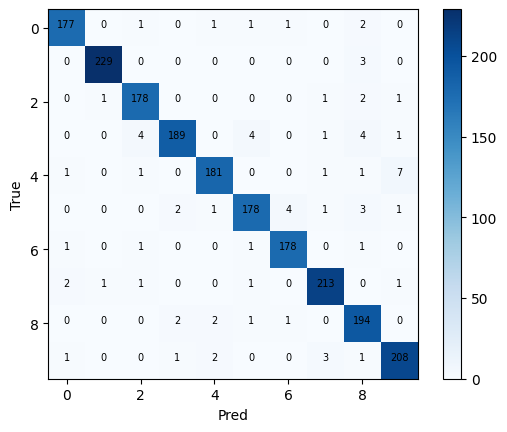

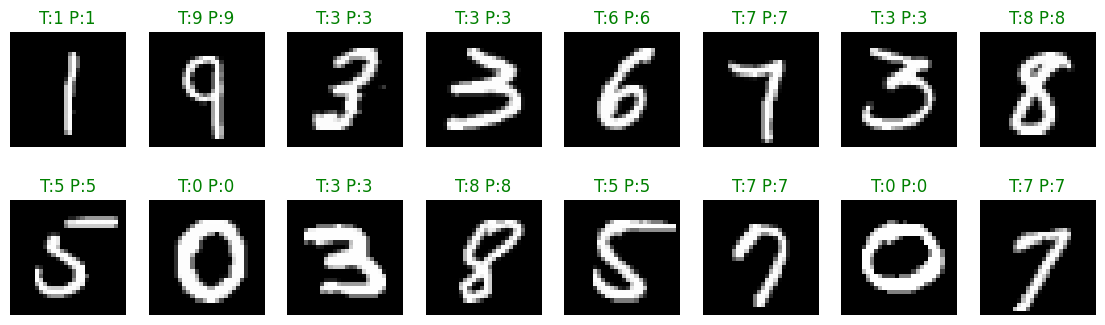

75 wrong


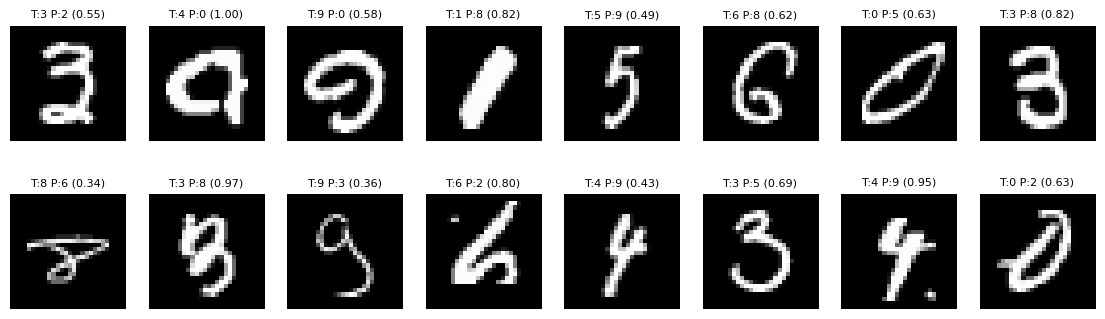

true 4 -> pred 9: 7
true 3 -> pred 5: 4
true 5 -> pred 6: 4
true 3 -> pred 2: 4
true 3 -> pred 8: 4


In [36]:
A2 = forward_prop(W1,b1,W2,b2,X_test)[3]; pred = A2.argmax(0)

cm = np.zeros((10,10), int)
np.add.at(cm, (Y_test, pred), 1)                 # rows=true, cols=predict
tp = np.diag(cm); P = tp/cm.sum(0); R = tp/cm.sum(1); F = 2*P*R/(P+R)
print("Accuracy:", tp.sum()/cm.sum())
print(pd.DataFrame({'precision':P, 'recall':R, 'f1':F}).round(3))
print("Macro P/R/F1:", P.mean().round(4), R.mean().round(4), F.mean().round(4))

plt.imshow(cm, cmap='Blues'); plt.colorbar(); plt.xlabel('Pred'); plt.ylabel('True')
for i in range(10):
    for j in range(10): plt.text(j, i, cm[i,j], ha='center', fontsize=7)
plt.show()

# sample predictions
fig, ax = plt.subplots(2, 8, figsize=(14, 4))
for a, i in zip(ax.ravel(), range(16)):
    a.imshow(X_test[:, i].reshape(28,28), cmap='gray'); a.axis('off')
    a.set_title(f"T:{Y_test[i]} P:{pred[i]}", color='g' if pred[i]==Y_test[i] else 'r')
plt.show()


wrong = np.where(pred != Y_test)[0]; print(len(wrong), "wrong")
fig, ax = plt.subplots(2, 8, figsize=(14, 4))
for a, i in zip(ax.ravel(), wrong[:16]):
    a.imshow(X_test[:, i].reshape(28,28), cmap='gray'); a.axis('off')
    a.set_title(f"T:{Y_test[i]} P:{pred[i]} ({A2[pred[i], i]:.2f})", fontsize=8)
plt.show()

# most confused pairs
c = cm.copy(); np.fill_diagonal(c, 0)
for f in np.argsort(c.ravel())[::-1][:5]: print(f"true {f//10} -> pred {f%10}: {c.ravel()[f]}")

0    0.099
1    0.115
2    0.102
3    0.097
4    0.098
5    0.088
6    0.096
7    0.103
8    0.104
9    0.098
Name: proportion, dtype: float64


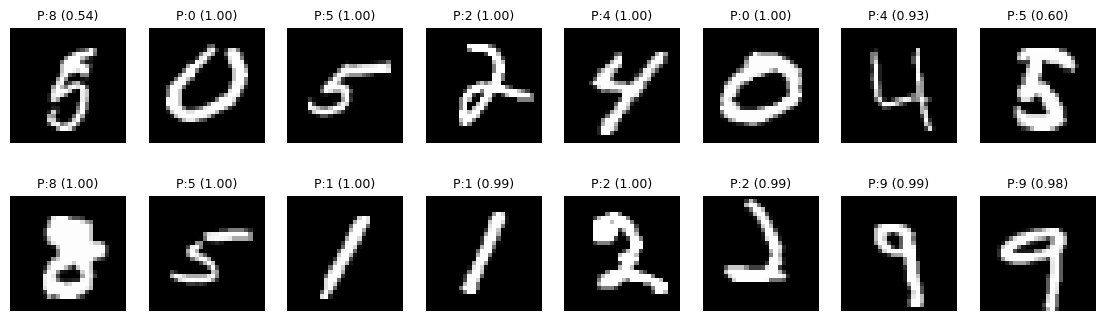

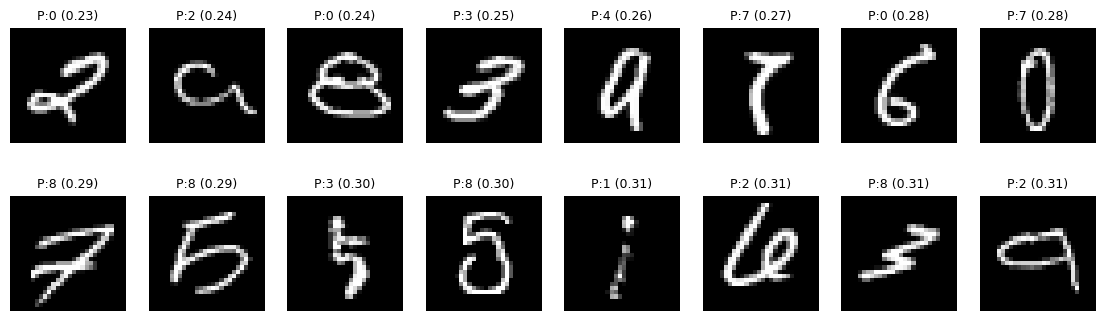

In [37]:
Xk = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv').values.T / 255   # (784, 28000)
Ak = forward_prop(W1, b1, W2, b2, Xk)[3]; pk = Ak.argmax(0)

# predicted class distribution (sanity check: should look roughly like the train distribution)
print(pd.Series(pk).value_counts(normalize=True).sort_index().round(3))

# visualize predictions with confidence
fig, ax = plt.subplots(2, 8, figsize=(14, 4))
for a, i in zip(ax.ravel(), np.random.choice(Xk.shape[1], 16, replace=False)):
    a.imshow(Xk[:, i].reshape(28, 28), cmap='gray'); a.axis('off')
    a.set_title(f"P:{pk[i]} ({Ak[pk[i], i]:.2f})", fontsize=9)
plt.show()

# least confident predictions (likely errors, since there are no labels to check against)
low = np.argsort(Ak.max(0))[:16]
fig, ax = plt.subplots(2, 8, figsize=(14, 4))
for a, i in zip(ax.ravel(), low):
    a.imshow(Xk[:, i].reshape(28, 28), cmap='gray'); a.axis('off')
    a.set_title(f"P:{pk[i]} ({Ak[pk[i], i]:.2f})", fontsize=9)
plt.show()

